<a href="https://colab.research.google.com/github/AlekhyaGangopadhyay/KrishiMitra_AI/blob/main/KrishiMitra_Split_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install split-folders


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import os
import shutil
import splitfolders
from google.colab import drive

# 1. MOUNT DRIVE
drive.mount('/content/drive')

# 2. DEFINE PATHS (Updated to MyDrive for better compatibility)
BASE_PATH = "/content/drive/My Drive/KrishiMitraAI"
LOCAL_DATA_DIR = os.path.join(BASE_PATH, "KrishiMitra_Dataset")
CLEANED_DIR = os.path.join(BASE_PATH, "KrishiMitra_Dataset_Split")
FINAL_SPLIT_DIR = os.path.join(BASE_PATH, "KrishiMitra_Final_Split")

# SAFETY CHECK: Let's see if the folder exists
if not os.path.exists(LOCAL_DATA_DIR):
    print(f"❌ ERROR: Cannot find {LOCAL_DATA_DIR}")
    print("Listing what IS in your KrishiMitraAI folder:")
    if os.path.exists(BASE_PATH):
        print(os.listdir(BASE_PATH))
    else:
        print(f"Base path {BASE_PATH} also not found. Check your Drive folder names!")
else:
    # 3. CLEAN AND MERGE
    print("🧹 Cleaning and Merging categories...")
    os.makedirs(CLEANED_DIR, exist_ok=True)

    for folder in os.listdir(LOCAL_DATA_DIR):
        folder_path = os.path.join(LOCAL_DATA_DIR, folder)

        if not os.path.isdir(folder_path) or "paddydoctor_test_images" in folder:
            continue

        # Standardize name
        new_name = folder.replace("_train", "").replace("_valid", "").replace("_test", "")
        target_path = os.path.join(CLEANED_DIR, new_name)
        os.makedirs(target_path, exist_ok=True)

        for img in os.listdir(folder_path):
            shutil.copy(os.path.join(folder_path, img), os.path.join(target_path, img))

    # 4. SPLIT
    print("🚀 Splitting into Train and Val (80/20)...")
    splitfolders.ratio(CLEANED_DIR, output=FINAL_SPLIT_DIR, seed=1337, ratio=(.8, .2))
    print(f"✅ SUCCESS! Data ready at: {FINAL_SPLIT_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🧹 Cleaning and Merging categories...
🚀 Splitting into Train and Val (80/20)...


Copying files: 44464 files [19:45, 37.52 files/s]

✅ SUCCESS! Data ready at: /content/drive/My Drive/KrishiMitraAI/KrishiMitra_Final_Split


Found 35556 images belonging to 40 classes.
Found 8908 images belonging to 40 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
🚀 Training on 40 categories...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
1112/1112 ━━━━━━━━━━━━━━━━━━━━ 855s 750ms/step - accuracy: 0.3258 - loss: 2.4967 - val_accuracy: 0.6365 - val_loss: 1.1972
Epoch 2/15
1112/1112 ━━━━━━━━━━━━━━━━━━━━ 768s 691ms/step - accuracy: 0.5814 - loss: 1.3612 - val_accuracy: 0.6856 - val_loss: 0.9994
Epoch 3/15
1112/1112 ━━━━━━━━━━━━━━━━━━━━ 754s 678ms/step - accuracy: 0.6308 - loss: 1.1606 - val_accuracy: 0.7072 - val_loss: 0.9094
Epoch 4/15
1112/1112 ━━━━━━━━━━━━━━━━━━━━ 752s 676ms/step - accuracy: 0.6607 - loss: 1.0495 - val_accuracy: 0.7215 - val_loss: 0.8567
Epoch 5/15
1112/1112 ━━━━━━━━━━━━━━━━━━━━ 730s 657ms/step - accuracy: 0.6838 - loss: 0.9825 - val_accuracy: 0.7307 - val_loss: 0.8275
Epoch 6/15
1112/1112 ━━━━━━━━━━━━━━━━━━━━ 716s 644ms/step - accuracy: 0.7050 - loss: 0.9166 - val_accuracy: 0.7462 - val_loss: 0.7801
Epoch 7/15
1112/1112 ━━━━━━━━━━━━━━━━━━━━ 705s 633ms/step - accuracy: 0.7081 - loss: 0.9025 - val_accuracy: 0.7500 - val_loss: 0.7691
Epoch 8/15
1112/1112 ━━━━━━━━━━━━━━━━━━━━ 710s 638ms/step - ac

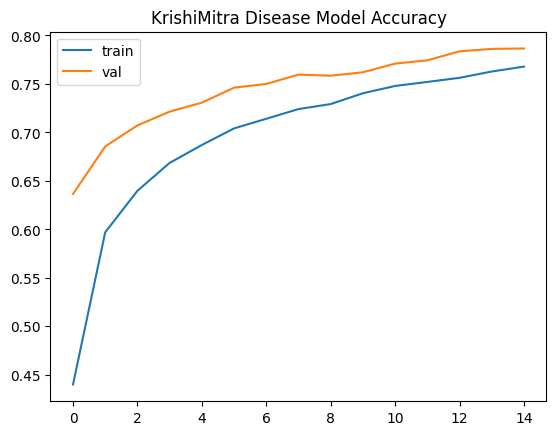

✅ SUCCESS! Model saved at /content/drive/MyDrive/KrishiMitraAI/KrishiMitra_Disease_Model.h5


In [6]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
import os

# --- 1. SETTINGS ---
# Use the folder path from your split result
TRAIN_DIR = '/content/drive/MyDrive/KrishiMitraAI/KrishiMitra_Final_Split/train'
VAL_DIR = '/content/drive/MyDrive/KrishiMitraAI/KrishiMitra_Final_Split/val'
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# --- 2. DATA AUGMENTATION ---
# This "fakes" more data for those small 20-image classes
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    VAL_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical'
)

# --- 3. BUILD THE MODEL ---
# Load MobileNetV2 without the top "brain"
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze the pre-trained weights

# Add our custom Krishi-specific head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# --- 4. COMPILE & TRAIN ---
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print(f"🚀 Training on {train_generator.num_classes} categories...")

history = model.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator
)

# --- 5. VISUALIZE & SAVE ---
# Plot Accuracy
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('KrishiMitra Disease Model Accuracy')
plt.legend()
plt.show()

# Save the model to your Drive
model_save_path = '/content/drive/MyDrive/KrishiMitraAI/KrishiMitra_Disease_Model.h5'
model.save(model_save_path)
print(f"✅ SUCCESS! Model saved at {model_save_path}")

In [7]:
import tensorflow as tf

# The model was saved at this path:
model_save_path = '/content/drive/MyDrive/KrishiMitraAI/KrishiMitra_Disease_Model.h5'

# Load the model
loaded_model = tf.keras.models.load_model(model_save_path)

print(f"✅ Model loaded successfully from: {model_save_path}")

✅ Model loaded successfully from: /content/drive/MyDrive/KrishiMitraAI/KrishiMitra_Disease_Model.h5


In [8]:
# Display the model summary to see its architecture
loaded_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,934,378 (11.19 MB)

 Trainable params: 676,392 (2.58 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 2 (12.00 B)